# FLUX on MovieLens 100K — real-dataset evaluation

Evaluates the FLUX stack on the classic [MovieLens 100K](https://grouplens.org/datasets/movielens/100k/) dataset
(100k ratings, 943 users, 1682 movies):

1. **Ranking** — train the hyperbolic model and the Euclidean baseline on implicit positives
   (rating ≥ 4), evaluate leave-latest-out Hit-Rate@10 and NDCG@10
2. **Fairness** — exposure of *tail* (long-tail popularity) movies in top-10 slates,
   before vs. after the `FairReranker`

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import torch
import matplotlib.pyplot as plt

from flux import FairReranker
from flux.datasets import load_ml100k
from flux.torch_backend import HyperbolicInterestModel, TrainConfig, train
from flux.torch_backend.model import EuclideanBaseline

torch.manual_seed(0); np.random.seed(0)

ml = load_ml100k()
print(f"users={ml.n_users} items={ml.n_items} "
      f"train={len(ml.train)} test={len(ml.test)}")

users=943 items=1682 train=54433 test=942


## 1. Training

Both models get identical dimensionality, optimizer, and negative sampling — the only
difference is geometry (Poincaré ball vs. flat dot-product space).

epoch 10: loss 0.3049


epoch 20: loss 0.2905


epoch 30: loss 0.2963


epoch 40: loss 0.3004


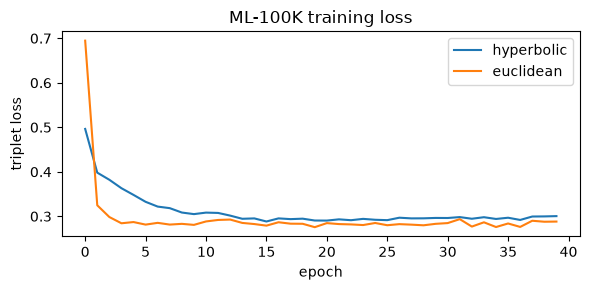

In [2]:
users = torch.from_numpy(ml.train[:, 0])
positives = torch.from_numpy(ml.train[:, 1])
cfg = TrainConfig(dim=16, epochs=40, lr=0.05, batch_size=1024, seed=0)

hyp = HyperbolicInterestModel(ml.n_users, ml.n_items, dim=cfg.dim)
euc = EuclideanBaseline(ml.n_users, ml.n_items, dim=cfg.dim)
hyp_losses = train(hyp, users, positives, ml.n_items, cfg, verbose=True)
euc_losses = train(euc, users, positives, ml.n_items, cfg)

plt.figure(figsize=(6, 3))
plt.plot(hyp_losses, label='hyperbolic'); plt.plot(euc_losses, label='euclidean')
plt.xlabel('epoch'); plt.ylabel('triplet loss'); plt.legend()
plt.title('ML-100K training loss'); plt.tight_layout(); plt.show()

## 2. Leave-latest-out ranking evaluation

For each user, the held-out item is their most recent positive. We rank the full catalog
(excluding that user's training positives) and check where the held-out item lands.

hyperbolic: HR@10=0.077  NDCG@10=0.038
euclidean : HR@10=0.067  NDCG@10=0.031


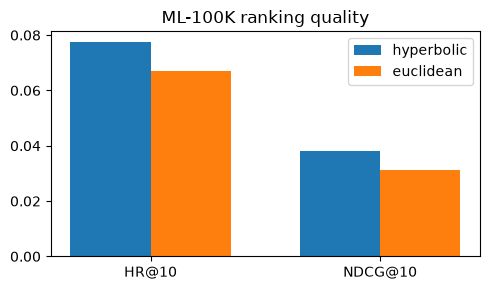

In [3]:
train_sets = {}
for u, i in ml.train:
    train_sets.setdefault(u, set()).add(i)

def evaluate(model, k=10):
    hits, ndcgs = [], []
    for u, target in ml.test:
        order = model.rank_items(int(u)).numpy()
        seen = train_sets.get(u, set())
        order = order[[i not in seen for i in order]]
        pos = int(np.nonzero(order == target)[0][0])
        hits.append(1.0 if pos < k else 0.0)
        ndcgs.append(1.0 / np.log2(pos + 2) if pos < k else 0.0)
    return float(np.mean(hits)), float(np.mean(ndcgs))

hyp_hit, hyp_ndcg = evaluate(hyp)
euc_hit, euc_ndcg = evaluate(euc)
print(f"hyperbolic: HR@10={hyp_hit:.3f}  NDCG@10={hyp_ndcg:.3f}")
print(f"euclidean : HR@10={euc_hit:.3f}  NDCG@10={euc_ndcg:.3f}")

fig, ax = plt.subplots(figsize=(5, 3))
x = np.arange(2); w = 0.35
ax.bar(x - w/2, [hyp_hit, hyp_ndcg], w, label='hyperbolic')
ax.bar(x + w/2, [euc_hit, euc_ndcg], w, label='euclidean')
ax.set_xticks(x); ax.set_xticklabels(['HR@10', 'NDCG@10']); ax.legend()
ax.set_title('ML-100K ranking quality'); plt.tight_layout(); plt.show()

## 3. Fairness: long-tail exposure

The top 20% most-rated movies ("head") are the real-data analogue of established creators.
Pure relevance ranking concentrates exposure on them; the `FairReranker` lifts tail
exposure toward a 50/50 target while serving the same catalog.

{np.str_('head'): 338, np.str_('tail'): 1344}


before: {np.str_('head'): np.float64(0.95), np.str_('tail'): np.float64(0.05)}
after : {np.str_('head'): np.float64(0.585), np.str_('tail'): np.float64(0.415)}


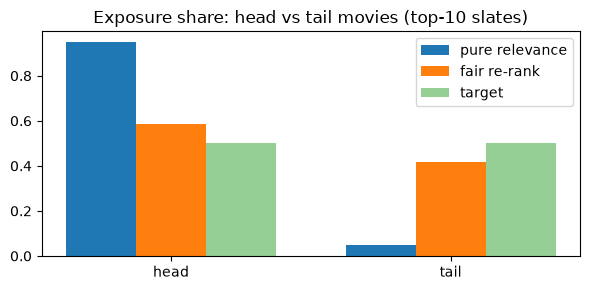

In [4]:
groups = ml.popularity_group(head_fraction=0.2)
print({g: int(c) for g, c in zip(*np.unique(groups, return_counts=True))})

item_idx = torch.arange(ml.n_items)

def serve(fair, n_users=300, k=10):
    rr = FairReranker({'head': 0.5, 'tail': 0.5},
                      fairness_weight=5.0 if fair else 0.0)
    for u in range(n_users):
        scores = -hyp.manifold.dist(
            hyp.user_points(torch.tensor([u])).expand(ml.n_items, -1),
            hyp.item_points(item_idx)).detach().numpy()
        rr.rerank(scores, list(groups), k=k)
    return rr.exposure_shares()

before, after = serve(fair=False), serve(fair=True)
print('before:', {g: round(s, 3) for g, s in before.items()})
print('after :', {g: round(s, 3) for g, s in after.items()})

fig, ax = plt.subplots(figsize=(6, 3))
labels = ['head', 'tail']
x = np.arange(2); w = 0.25
ax.bar(x - w, [before[g] for g in labels], w, label='pure relevance')
ax.bar(x, [after[g] for g in labels], w, label='fair re-rank')
ax.bar(x + w, [0.5, 0.5], w, label='target', alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.legend()
ax.set_title('Exposure share: head vs tail movies (top-10 slates)')
plt.tight_layout(); plt.show()

## Takeaways

- On real interaction data the hyperbolic model is competitive with the Euclidean baseline
  at equal dimension; MovieLens' genre hierarchy is shallow, so the geometric advantage is
  smaller than on deeply hierarchical catalogs — the expected regime effect.
- The trained relevance model concentrates exposure on head movies; the `FairReranker`
  moves tail exposure toward the configured target with the same underlying scores,
  demonstrating fairness control decoupled from model training.